In [1]:
# %%capture
!pip install -U torch pytorch-lightning
# scikit-learn imbalanced-learn numpy lightning-fabric


[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


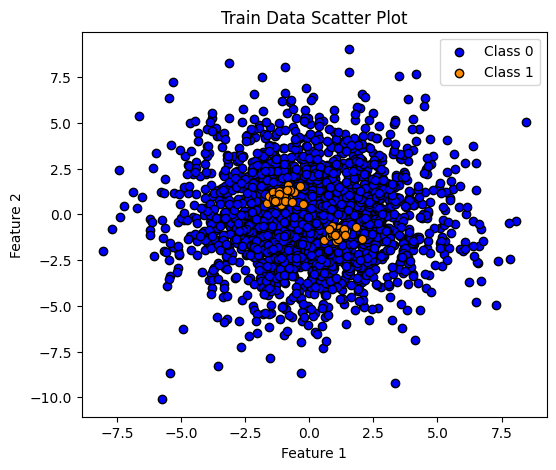

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | model     | Sequential        | 2.3 K  | train
1 | criterion | BCEWithLogitsLoss | 0      | train
--------------------------------------------------------
2.3 K     Trainable params
0         Non-trainable params
2.3 K     Total params
0.009     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/

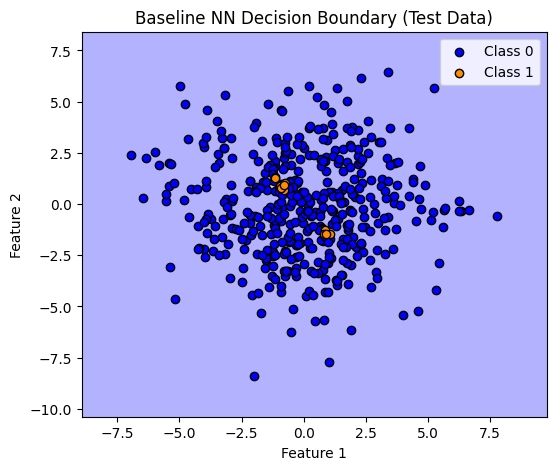

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | model     | Sequential        | 2.3 K  | train
1 | criterion | BCEWithLogitsLoss | 0      | train
--------------------------------------------------------
2.3 K     Trainable params
0         Non-trainable params
2.3 K     Total params
0.009     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | model     | Sequential        | 2.3 K  | train
1 | criterion | BCEWithLogitsLoss | 0      | train
--------------------------------------------------------
2.3 K     Trainable params
0         Non-trainabl


==== Underbagging Ensemble Result ====
ROC AUC: 0.9605
Confusion Matrix:
 [[360  80]
 [  0  10]]
Classification Report:
               precision    recall  f1-score   support

           0     1.0000    0.8182    0.9000       440
           1     0.1111    1.0000    0.2000        10

    accuracy                         0.8222       450
   macro avg     0.5556    0.9091    0.5500       450
weighted avg     0.9802    0.8222    0.8844       450



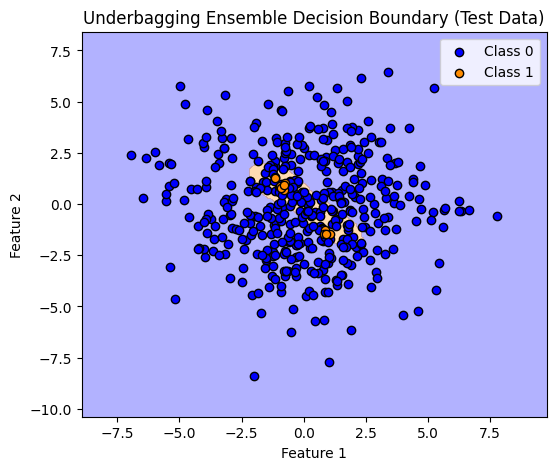

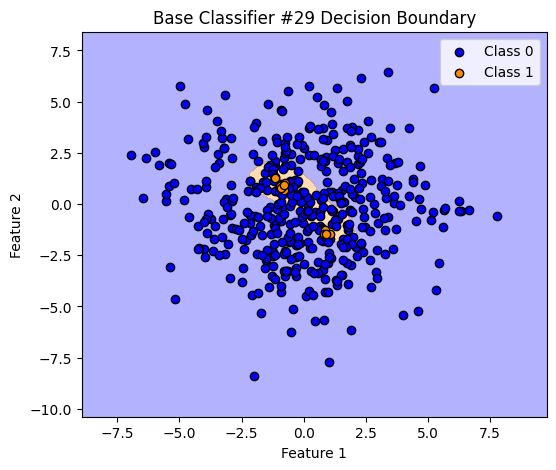

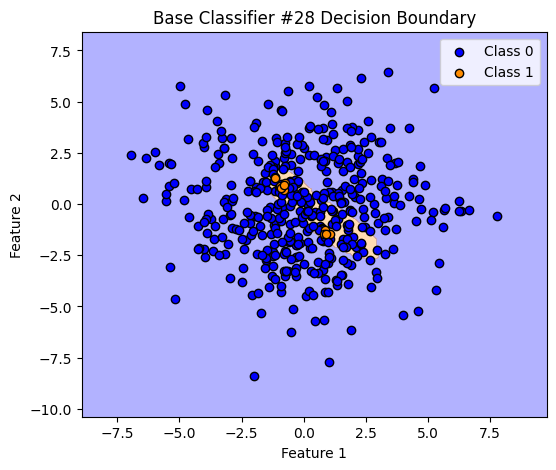

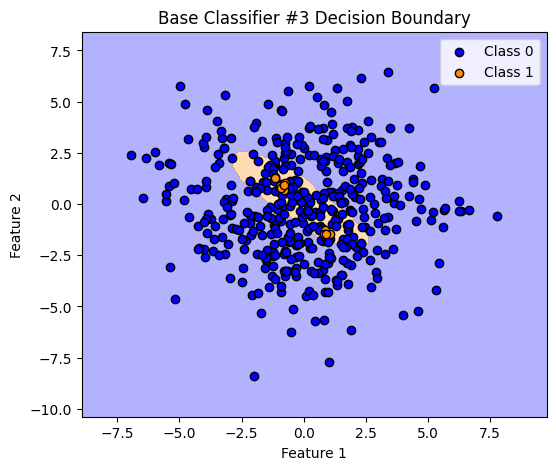

In [13]:
#############################
# 1. 必要なライブラリのインポートとシードの固定
#############################
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_classification
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# シード固定
SEED = 94
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#############################
# 2. カラーパレットの定義
#############################
color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080",
}

# バイナリ分類用にクラス0(多数派)をblue, クラス1(少数派)をdark_orangeで可視化
class_colors = [color_palette["blue"], color_palette["dark_orange"]]
region_cmap = ListedColormap(class_colors)

#############################
# 3. データ生成
#############################
# Majority cluster (large, wide)
X_maj, _ = make_blobs(
    n_samples=2910,
    centers=[[0, 0]],
    cluster_std=[2.5],
    random_state=SEED
)
y_maj = np.zeros(2910, dtype=int)

# Minority cluster 1 (small, compact)
X_min1, _ = make_blobs(
    n_samples=45,
    centers=[[1, -1]],
    cluster_std=[0.3],
    random_state=SEED + 1
)
y_min1 = np.ones(45, dtype=int)

# Minority cluster 2 (small, compact)
X_min2, _ = make_blobs(
    n_samples=45,
    centers=[[-1, 1]],
    cluster_std=[0.3],
    random_state=SEED + 2
)
y_min2 = np.ones(45, dtype=int)

# Combine majority + minority
X = np.vstack([X_maj, X_min1, X_min2])
y = np.hstack([y_maj, y_min1, y_min2])

# Shuffle
indices = np.arange(len(y))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

# Train/Val/Test split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=SEED)

#############################
# 4. 可視化関数の定義
#############################
def plot_data_scatter(X_data, y_data, title="Data Scatter Plot"):
    plt.figure(figsize=(6,5))
    for cls in [0,1]:
        idxs = (y_data == cls)
        plt.scatter(X_data[idxs, 0], X_data[idxs, 1],
                    color=class_colors[cls],
                    edgecolors=color_palette["black"],
                    label=f"Class {cls}")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

def plot_decision_regions(model, X_data, y_data=None, title="Decision Boundary", show_data=True):
    x_min = X_data[:,0].min() - 2.0
    x_max = X_data[:,0].max() + 2.0
    y_min = X_data[:,1].min() - 2.0
    y_max = X_data[:,1].max() + 2.0
    step = 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        logits = model(grid_tensor)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()
        preds = (probs >= 0.5).astype(int)
    Z = preds.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap=region_cmap, alpha=0.3)
    if show_data and y_data is not None:
        for cls in [0,1]:
            idxs = (y_data == cls)
            plt.scatter(X_data[idxs, 0], X_data[idxs, 1],
                        color=class_colors[cls],
                        edgecolors=color_palette["black"],
                        label=f"Class {cls}")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

#############################
# 5. テンソル変換 & DataModule
#############################
import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

class BinaryDataModule(pl.LightningDataModule):
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, batch_size=32):
        super().__init__()
        self.batch_size = batch_size
        self.X_train = X_train
        self.y_train = y_train
        self.X_val   = X_val
        self.y_val   = y_val
        self.X_test  = X_test
        self.y_test  = y_test

    def setup(self, stage=None):
        self.train_dataset = TensorDataset(self.X_train, self.y_train)
        self.val_dataset   = TensorDataset(self.X_val, self.y_val)
        self.test_dataset  = TensorDataset(self.X_test, self.y_test)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False)

data_module = BinaryDataModule(X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t, batch_size=32)

#############################
# 6. NNモデル定義 (PyTorch Lightning)
#############################
class BinaryClassifier(pl.LightningModule):
    def __init__(self, input_dim=2, hidden1=64, hidden2=32, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1)
        )
        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=False)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.sigmoid(logits) >= 0.5
        acc = (preds.float() == y).float().mean()
        self.log("test_loss", loss, prog_bar=False)
        self.log("test_acc", acc, prog_bar=False)
        return {"loss": loss, "acc": acc}

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.hparams.lr)

#############################
# 7. 実験: Baseline (単一NN) と Underbagging Ensemble
#############################
# 7.1. 初期散布図でデータを可視化
plot_data_scatter(X_train, y_train, title="Train Data Scatter Plot")

# 7.2. Baseline モデルの学習
early_stop_callback = EarlyStopping(monitor="val_loss", patience=10, mode="min", verbose=False)
trainer_baseline = pl.Trainer(
    max_epochs=50,
    callbacks=[early_stop_callback],
    deterministic=True,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=False
)

baseline_model = BinaryClassifier()
trainer_baseline.fit(baseline_model, datamodule=data_module)
trainer_baseline.test(baseline_model, datamodule=data_module, verbose=False)

plot_decision_regions(baseline_model, X_test, y_test, title="Baseline NN Decision Boundary (Test Data)")

# 7.3. Underbagging Ensemble
n_ensemble = 30
ensemble_models = []

y_train_np = y_train  # numpy配列
indices_minority = np.where(y_train_np == 1)[0]
indices_majority = np.where(y_train_np == 0)[0]
n_minority = len(indices_minority)

for i in range(n_ensemble):
    sampled_majority = np.random.choice(indices_majority, size=n_minority, replace=False)
    selected_indices = np.concatenate([indices_minority, sampled_majority])
    np.random.shuffle(selected_indices)

    X_sub = X_train[selected_indices]
    y_sub = y_train_np[selected_indices]
    X_sub_t = torch.tensor(X_sub, dtype=torch.float32)
    y_sub_t = torch.tensor(y_sub, dtype=torch.float32).unsqueeze(1)
    sub_dataset = TensorDataset(X_sub_t, y_sub_t)
    sub_loader = DataLoader(sub_dataset, batch_size=32, shuffle=True)

    sub_model = BinaryClassifier()
    trainer_sub = pl.Trainer(
        max_epochs=200,
        callbacks=[EarlyStopping(monitor="val_loss", patience=10, mode="min", verbose=False)],
        deterministic=True,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False
    )
    trainer_sub.fit(sub_model, train_dataloaders=sub_loader, val_dataloaders=data_module.val_dataloader())
    ensemble_models.append(sub_model)

def ensemble_predict(models, X_input):
    X_tensor = torch.tensor(X_input, dtype=torch.float32)
    preds_list = []
    for model in models:
        model.eval()
        with torch.no_grad():
            logits = model(X_tensor)
            prob = torch.sigmoid(logits).squeeze().cpu().numpy()
            preds_list.append(prob)
    avg_prob = np.mean(preds_list, axis=0)
    return avg_prob

ensemble_probs = ensemble_predict(ensemble_models, X_test)
ensemble_preds = (ensemble_probs >= 0.5).astype(int)

# 評価
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
roc_auc = roc_auc_score(y_test, ensemble_probs)
cm = confusion_matrix(y_test, ensemble_preds)
clf_report = classification_report(y_test, ensemble_preds, digits=4)

print("\n==== Underbagging Ensemble Result ====")
print(f"ROC AUC: {roc_auc:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", clf_report)

def plot_ensemble_decision_regions(models, X_data, y_data=None, title="Ensemble Decision Boundary"):
    x_min = X_data[:,0].min() - 2.0
    x_max = X_data[:,0].max() + 2.0
    y_min = X_data[:,1].min() - 2.0
    y_max = X_data[:,1].max() + 2.0
    step = 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    avg_prob = ensemble_predict(models, grid_points)
    Z = (avg_prob >= 0.5).astype(int).reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], cmap=region_cmap, alpha=0.3)
    if y_data is not None:
        for cls in [0,1]:
            idxs = (y_data == cls)
            plt.scatter(X_data[idxs, 0], X_data[idxs, 1],
                        color=class_colors[cls],
                        edgecolors=color_palette["black"],
                        label=f"Class {cls}")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

plot_ensemble_decision_regions(ensemble_models, X_test, y_test, title="Underbagging Ensemble Decision Boundary (Test Data)")

#############################
# 8. Visualize Some Base Classifiers
#############################
def plot_some_base_classifiers(models, X_data, y_data, num_submodels=3):
    """
    Randomly pick a few base classifiers from the ensemble
    and plot their decision boundaries on the given (X_data, y_data).
    """
    chosen_indices = np.random.choice(len(models), size=num_submodels, replace=False)
    for idx in chosen_indices:
        sub_model = models[idx]
        plot_decision_regions(
            sub_model,
            X_data,
            y_data,
            title=f"Base Classifier #{idx} Decision Boundary"
        )

# Let's visualize 3 random base classifiers on the test data
plot_some_base_classifiers(ensemble_models, X_test, y_test, num_submodels=3)